In [1]:
# Parameters
USE_SPACY = "true"
DATA_DIR = "."
TRAIN_CSV = "train.csv"
VAL_CSV = "val.csv"
TEST_CSV = "test.csv"
SAVE_DIR = "/home/santoshd/hvsm/weights"
MAX_TRAIN_TIME_PER_MODEL_MIN = 160
EARLY_DROP_MIN = 25
EARLY_DROP_F1 = 0.68
N_FOLDS = 3
MAX_SEQ_LEN = 256
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 64
GRAD_ACCUM_STEPS = 2
MIXED_PRECISION = "bf16"
GRADIENT_CHECKPOINTING = "true"
PIN_MEMORY = "true"
NUM_WORKERS = 4
PREFETCH_FACTOR = 2
PERSISTENT_WORKERS = "true"
DATALOADER_MEMORY_EFFICIENT = "true"
KEEP_IN_MEMORY = "false"
SAVE_ONLY_BEST = "true"
SAVE_EVERY_FOLD = "true"
LOG_ARTIFACTS_TO_NOTEBOOK = "false"
PLOT_LEVEL = "light"
BASE_MODEL_NAME = "distilbert-base-uncased"
TFIDF_MAX_FEATS = 50000
TEXT_COL = "text"
LABEL_COL = "label"
RANDOM_SEED = 42


# Kaggle Baseline: TF–IDF + XGBoost + Logistic Regression

This notebook implements the exact baseline pipeline you provided, with documentation, type hints, assertions, and diagnostic plots. It expects `train.csv`, `val.csv`, and `test.csv` to reside in the same directory. The outputs include validation reports and a `submission.csv` file for Kaggle.

The workflow:
1. Load CSVs and engineer basic text features.
2. Compute TF–IDF up to trigrams.
3. Train XGBoost and Logistic Regression models.
4. Calibrate via Platt scaling.
5. Ensemble (weighted average) and threshold tune on validation.
6. Generate predictions on `test.csv`.

Additional diagnostics: QQ plot, residual plot, violin plot, and a brief sanity audit of the inputs.

In [2]:
from __future__ import annotations

from typing import List, Tuple
import os
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report, f1_score
)
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
from scipy import stats
try:
    import seaborn as sns  # optional, for violin plots
except Exception:  # pragma: no cover
    sns = None

try:
    from textblob import TextBlob
except Exception as e:  # pragma: no cover
    TextBlob = None
    warnings.warn(
        'TextBlob not available; sentiment features will be zeros.'
    )


/tmp/ipykernel_3175545/1712114975.py:32: UserWarning: TextBlob not available; sentiment features will be zeros.
  warnings.warn(


## Utilities and plotting

In [3]:
def qq_plot(residuals: np.ndarray, title: str) -> None:
    """Draw a QQ plot of residuals.

    Args:
        residuals: Array of residuals.
        title: Plot title.
    """
    plt.figure(figsize=(5, 4))
    stats.probplot(residuals, dist='norm', plot=plt)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def residual_plot(y_true: np.ndarray, y_prob: np.ndarray,
                  title: str) -> None:
    """Scatter residuals vs predicted probabilities.

    Args:
        y_true: True binary labels.
        y_prob: Predicted probabilities for the positive class.
        title: Plot title.
    """
    resid = y_true - y_prob
    plt.figure(figsize=(5, 4))
    plt.scatter(y_prob, resid, s=8)
    plt.axhline(0.0, linestyle='--')
    plt.xlabel('p(y=1)')
    plt.ylabel('residual')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def violin_by_label(df: pd.DataFrame, label_col: str,
                    feat_col: str, title: str) -> None:
    """Violin plot of a numeric feature split by label.

    Args:
        df: DataFrame containing labels and the feature.
        label_col: Name of the label column.
        feat_col: Name of the numeric feature column.
        title: Plot title.
    """
    if sns is None:  # fallback to simple boxplot if seaborn missing
        plt.figure(figsize=(5, 4))
        df.boxplot(column=feat_col, by=label_col)
        plt.title(title)
        plt.suptitle('')
        plt.tight_layout()
        plt.show()
        return
    plt.figure(figsize=(5, 4))
    sns.violinplot(data=df, x=label_col, y=feat_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Data loading and processing

In [4]:
def process_text_file(filename: str) -> pd.DataFrame:
    """Load CSV and compute simple text-derived features.

    The file is expected to contain at least a `text` column, and, for
    training/validation, a `label` column.

    Args:
        filename: CSV path relative to the notebook directory.

    Returns:
        DataFrame with additional feature columns.

    Raises:
        AssertionError: If required columns are missing.
    """
    df = pd.read_csv(os.path.join(filename))
    assert 'text' in df.columns, 'CSV must contain a text column.'
    df['text'] = df['text'].astype(str)

    df['text_length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()
    df['sentence_count'] = (
        df['text'].str.count(r'[.!?]+').replace(0, 1)
    )
    df['avg_sentence_length'] = (
        (df['word_count'] / df['sentence_count']).clip(upper=100)
    )
    df['punct_count'] = df['text'].str.count(r'[^\w\s]')
    df['punct_ratio'] = (
        (df['punct_count'] / df['text_length']).clip(0, 0.3)
    )

    def ttr(text: str) -> float:
        words = re.findall(r'\S+', text.lower())
        return len(set(words)) / len(words) if len(words) > 0 else 0.0

    tqdm.pandas()
    df['ttr'] = df['text'].progress_apply(ttr)
    return df


## TF–IDF features

In [5]:
def add_ngram_tfidf(
    train_texts: pd.Series,
    valid_texts: pd.Series,
    test_texts: pd.Series,
    n: int = 3,
    max_features: int = 5000,
) -> Tuple[csr_matrix, csr_matrix, csr_matrix]:
    """Build an n-gram TF–IDF representation.

    Args:
        train_texts: Training texts.
        valid_texts: Validation texts.
        test_texts: Test texts.
        n: Maximum n-gram size.
        max_features: Vocabulary size cap.

    Returns:
        Tuple of sparse matrices (train, valid, test).
    """
    vectorizer = TfidfVectorizer(
        ngram_range=(1, n), max_features=max_features,
        stop_words='english'
    )
    X_train_ng = vectorizer.fit_transform(train_texts)
    X_valid_ng = vectorizer.transform(valid_texts)
    X_test_ng = vectorizer.transform(test_texts)
    return X_train_ng, X_valid_ng, X_test_ng


## Sentiment features

In [6]:
def add_sentiment_features(df: pd.DataFrame) -> pd.DataFrame:
    """Attach TextBlob sentiment features.

    If TextBlob is unavailable, the features are set to zeros with a
    warning.

    Args:
        df: DataFrame with `text` column.

    Returns:
        DataFrame with `sentiment_polarity` and `sentiment_subjectivity`.
    """
    tqdm.pandas()
    if TextBlob is None:
        df['sentiment_polarity'] = 0.0
        df['sentiment_subjectivity'] = 0.0
        return df

    def _pol(x: str) -> float:
        return float(TextBlob(x).sentiment.polarity)

    def _subj(x: str) -> float:
        return float(TextBlob(x).sentiment.subjectivity)

    df['sentiment_polarity'] = df['text'].progress_apply(_pol)
    df['sentiment_subjectivity'] = df['text'].progress_apply(_subj)
    return df


## Load data (train/val/test)

In [7]:
# Strict file names in the same directory as this notebook
train = process_text_file('train.csv')
validation = process_text_file('val.csv')
test = process_text_file('test.csv')

# Basic schema checks
for name, df in [('train', train), ('val', validation), ('test', test)]:
    assert 'text' in df.columns, f"{name} missing 'text' column"
assert 'label' in train.columns, 'train must have label'
assert 'label' in validation.columns, 'val must have label'
assert 'label' not in test.columns, 'test must NOT have label'

print('Rows: train', len(train), ' val', len(validation), ' test', len(test))

  0%|          | 0/319071 [00:00<?, ?it/s]

  0%|          | 1458/319071 [00:00<00:21, 14576.89it/s]

  1%|          | 2916/319071 [00:00<00:24, 12880.88it/s]

  2%|▏         | 5721/319071 [00:00<00:16, 19338.87it/s]

  3%|▎         | 8986/319071 [00:00<00:12, 24371.83it/s]

...

 87%|████████▋ | 53049/60743 [00:03<00:00, 23743.94it/s]

 92%|█████████▏| 55905/60743 [00:03<00:00, 23869.39it/s]

 97%|█████████▋| 58630/60743 [00:03<00:00, 20981.30it/s]

100%|██████████| 60743/60743 [00:03<00:00, 16997.03it/s]

Rows: train 319071  val 56792  test 60743


## Add sentiment features

In [8]:
train = add_sentiment_features(train)
validation = add_sentiment_features(validation)
test = add_sentiment_features(test)


## Assemble features

In [9]:
feature_cols: List[str] = [
    'text_length', 'word_count', 'ttr', 'sentence_count',
    'avg_sentence_length', 'punct_ratio',
    'sentiment_polarity', 'sentiment_subjectivity',
]

X_train_basic = train[feature_cols]
X_valid_basic = validation[feature_cols]
X_test_basic = test[feature_cols]

X_train_ngram, X_valid_ngram, X_test_ngram = add_ngram_tfidf(
    train['text'], validation['text'], test['text'],
    n=3, max_features=5000
)

X_train = hstack([csr_matrix(X_train_basic.values), X_train_ngram])
X_valid = hstack([csr_matrix(X_valid_basic.values), X_valid_ngram])
X_test = hstack([csr_matrix(X_test_basic.values), X_test_ngram])

y_train = train['label']
y_valid = validation['label']

print('Shapes:')
print('  X_train:', X_train.shape)
print('  X_valid:', X_valid.shape)
print('  X_test :', X_test.shape)

Shapes:
  X_train: (319071, 5008)
  X_valid: (56792, 5008)
  X_test : (60743, 5008)


## Class balance and scale_pos_weight

In [10]:
counter = Counter(y_train)
assert 0 in counter and 1 in counter, 'labels must be binary {0,1}'
scale_pos_weight = counter[0] / counter[1]
print('Class counts:', counter)
print('scale_pos_weight:', scale_pos_weight)

Class counts: Counter({0: 225753, 1: 93318})
scale_pos_weight: 2.4191795795023467


## Train XGBoost and Logistic Regression

In [11]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
)
xgb.fit(X_train, y_train)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print('Models trained.')

/home/santoshd/hvsm/hvsm_venv_34940677/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [03:15:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Models trained.


/home/santoshd/hvsm/hvsm_venv_34940677/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Calibrate with Platt scaling

In [12]:
calibrated_xgb = CalibratedClassifierCV(xgb, method='sigmoid',
                                        cv='prefit')
calibrated_xgb.fit(X_valid, y_valid)

calibrated_lr = CalibratedClassifierCV(lr, method='sigmoid',
                                       cv='prefit')
calibrated_lr.fit(X_valid, y_valid)
print('Models calibrated.')

Models calibrated.


## Ensemble and threshold tuning

In [13]:
val_pred_proba_xgb = calibrated_xgb.predict_proba(X_valid)[:, 1]
val_pred_proba_lr = calibrated_lr.predict_proba(X_valid)[:, 1]
val_pred_proba_ensemble = (
    0.6 * val_pred_proba_xgb + 0.4 * val_pred_proba_lr
)

thresholds = np.arange(0.1, 0.9, 0.01)
best_threshold = 0.5
best_f1 = -1.0

for thr in thresholds:
    val_pred_thr = (val_pred_proba_ensemble >= thr).astype(int)
    f1 = f1_score(y_valid, val_pred_thr)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = float(thr)

print(
    f'Best threshold: {best_threshold:.2f} with F1: {best_f1:.4f}'
)

Best threshold: 0.43 with F1: 0.8400


## Validation report and diagnostics

              precision    recall  f1-score   support

           0       0.87      0.77      0.82     27993
           1       0.80      0.88      0.84     28799

    accuracy                           0.83     56792
   macro avg       0.83      0.83      0.83     56792
weighted avg       0.83      0.83      0.83     56792



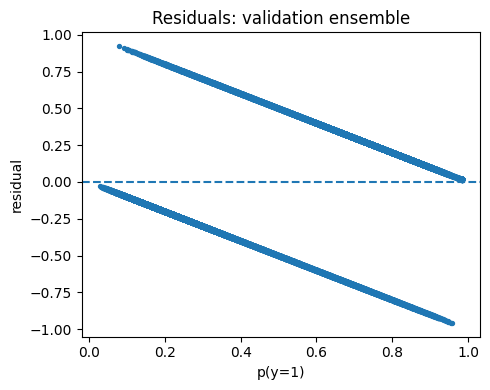

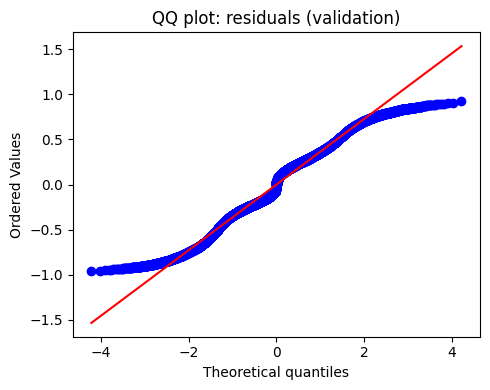

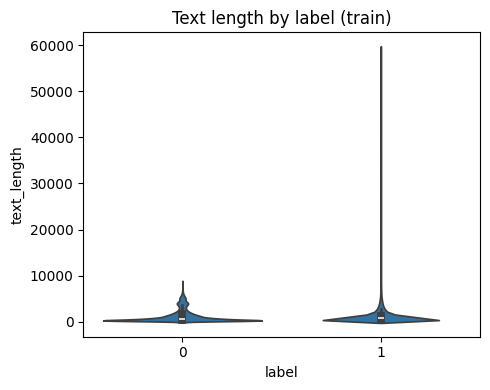

In [14]:
val_pred_final = (val_pred_proba_ensemble >= best_threshold).astype(int)
print(classification_report(y_valid, val_pred_final))

# Diagnostics
residual_plot(y_valid.to_numpy(), val_pred_proba_ensemble,
              'Residuals: validation ensemble')
qq_plot(y_valid.to_numpy() - val_pred_proba_ensemble,
        'QQ plot: residuals (validation)')
try:
    # Violin on a basic feature (train) to visualize label differences
    violin_by_label(train, 'label', 'text_length',
                    'Text length by label (train)')
except Exception as e:
    warnings.warn(f'Violin plot skipped: {e}')


## Predict on test and write submission

In [15]:
test_pred_proba_xgb = calibrated_xgb.predict_proba(X_test)[:, 1]
test_pred_proba_lr = calibrated_lr.predict_proba(X_test)[:, 1]
test_pred_proba_ensemble = (
    0.6 * test_pred_proba_xgb + 0.4 * test_pred_proba_lr
)
test_pred_final = (
    test_pred_proba_ensemble >= best_threshold
).astype(int)

assert 'id' in test.columns, "test.csv must contain an 'id' column."
submission = pd.DataFrame({
    'id': test['id'],
    'label': test_pred_final,
})
submission.to_csv('submission.csv', index=False)
print('Submission saved to submission.csv')


Submission saved to submission.csv
